# Lab 15 — EfficientNet-B0 Baseline
## Deepfake Detection for Video KYC

This experiment trains **pretrained EfficientNet-B0** on the same complete FaceForensics KYC dataset and uses the same train/validation/test protocol as Lab 14.

**Baseline reference:** MobileNetV2 — Test Accuracy 90.24%, ROC-AUC 0.9020.

The purpose of Lab 15 is a fair architecture comparison. Do not change the test set or evaluation protocol.

## 1. Environment setup
The notebook is designed for Google Colab with a T4 GPU. It does not require Google Drive mounting.

In [1]:
!pip install -q kaggle scikit-learn

In [2]:
import os
import sys
import json
import shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

Running in Colab: True


## 2. Project setup

In [3]:
REPO_URL = "https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git"
REPO_NAME = "Deepfake-Detection-KYC"

if IN_COLAB:
    os.chdir("/content")
    if not Path(REPO_NAME).exists():
        result = os.system(f"git clone {REPO_URL}")
        if result != 0:
            raise RuntimeError("Git clone failed.")
    os.chdir(REPO_NAME)

PROJECT_ROOT = Path.cwd()
print("Project root:", PROJECT_ROOT)

Project root: /content/Deepfake-Detection-KYC


In [4]:
# Locate the project's FaceDataset implementation.
dataset_file = PROJECT_ROOT / "src" / "dataset" / "dataloader.py"
if not dataset_file.exists():
    raise FileNotFoundError(f"Missing expected dataset file: {dataset_file}")

sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset.dataloader import FaceDataset

import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision import transforms
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA available: True
GPU: Tesla T4


## 3. Kaggle authentication

In [5]:
from google.colab import userdata

def load_kaggle_credentials():
    if not IN_COLAB:
        print("Not in Colab; assuming Kaggle credentials are already configured.")
        return

    token = userdata.get("KAGGLE_API_TOKEN")
    if not token:
        raise RuntimeError(
            "KAGGLE_API_TOKEN was not found in Colab Secrets. "
            "Add your Kaggle token as a Colab secret named KAGGLE_API_TOKEN."
        )

    os.environ["KAGGLE_API_TOKEN"] = token
    print("Kaggle token loaded:", True)

load_kaggle_credentials()

Kaggle token loaded: True


## 4. Dataset download / reuse
The notebook uses one canonical location: `PROJECT_ROOT/data/kaggle_processed`. If it already contains the complete dataset, it reuses it.

In [6]:
KAGGLE_DATASET_SLUG = "aishwarya99990/faceforensics-kyc-processed"
DATASET_ROOT = PROJECT_ROOT / "data" / "kaggle_processed"
DATASET_ROOT.parent.mkdir(parents=True, exist_ok=True)

def count_jpgs(folder):
    return len(list(Path(folder).glob("*.jpg"))) if Path(folder).exists() else 0

expected_raw_counts = {
    "train": {"real": 4965, "fake": 24744},
    "val":   {"real": 1082, "fake": 5475},
    "test":  {"real": 1059, "fake": 5377},
}

def current_counts(root):
    return {
        split: {label: count_jpgs(Path(root) / split / label)
                for label in ("real", "fake")}
        for split in ("train", "val", "test")
    }

counts_before = current_counts(DATASET_ROOT)
print("Existing counts:", counts_before)

complete_exists = all(
    counts_before[s][l] >= expected_raw_counts[s][l]
    for s in expected_raw_counts for l in expected_raw_counts[s]
)

if not complete_exists:
    print("Complete dataset not found. Downloading from Kaggle...")
    if DATASET_ROOT.exists():
        shutil.rmtree(DATASET_ROOT)

    DATASET_ROOT.mkdir(parents=True, exist_ok=True)

    download_cmd = (
        f'kaggle datasets download -d "{KAGGLE_DATASET_SLUG}" '
        f'-p "{DATASET_ROOT}" --unzip'
    )
    result = os.system(download_cmd)
    if result != 0:
        raise RuntimeError("Kaggle dataset download failed.")

print("Dataset root:", DATASET_ROOT)

Existing counts: {'train': {'real': 0, 'fake': 0}, 'val': {'real': 0, 'fake': 0}, 'test': {'real': 0, 'fake': 0}}
Complete dataset not found. Downloading from Kaggle...
Dataset root: /content/Deepfake-Detection-KYC/data/kaggle_processed


## 5. Dataset structure and integrity check
A zero-byte or unreadable image must never reach a DataLoader worker.

In [7]:
from PIL import Image

def verify_structure(root):
    missing = []
    for split in ("train", "val", "test"):
        for label in ("real", "fake"):
            folder = root / split / label
            if not folder.exists():
                missing.append(str(folder))
    if missing:
        raise RuntimeError("Missing dataset folders:\n" + "\n".join(missing))

def find_bad_images(root):
    bad = []
    for split in ("train", "val", "test"):
        for label in ("real", "fake"):
            folder = root / split / label
            for path in folder.glob("*.jpg"):
                try:
                    if path.stat().st_size == 0:
                        raise ValueError("zero-byte file")
                    with Image.open(path) as img:
                        img.verify()
                except Exception as exc:
                    bad.append((path, repr(exc)))
    return bad

verify_structure(DATASET_ROOT)

downloaded_counts = current_counts(DATASET_ROOT)
print("Downloaded counts:")
for split, labels in downloaded_counts.items():
    print(split.upper(), labels)

for split in expected_raw_counts:
    for label in expected_raw_counts[split]:
        actual = downloaded_counts[split][label]
        expected = expected_raw_counts[split][label]
        if actual < expected:
            raise RuntimeError(
                f"{split}/{label} has {actual} images, but {expected} were expected. "
                "The dataset appears incomplete; stopping before training."
            )

bad_files = find_bad_images(DATASET_ROOT)
print("\nCorrupted/unreadable images:", len(bad_files))

if bad_files:
    quarantine = PROJECT_ROOT / "outputs" / "dataset_quarantine"
    quarantine.mkdir(parents=True, exist_ok=True)

    for path, reason in bad_files:
        relative = path.relative_to(DATASET_ROOT)
        destination = quarantine / relative
        destination.parent.mkdir(parents=True, exist_ok=True)
        shutil.move(str(path), str(destination))
        print("Quarantined:", relative, "|", reason)

remaining_bad = find_bad_images(DATASET_ROOT)
print("Remaining corrupted images:", len(remaining_bad))

if remaining_bad:
    raise RuntimeError("Unreadable images remain. Training stopped.")

Downloaded counts:
TRAIN {'real': 4965, 'fake': 24744}
VAL {'real': 1082, 'fake': 5475}
TEST {'real': 1059, 'fake': 5377}

Corrupted/unreadable images: 0
Remaining corrupted images: 0


## 6. Final dataset counts

In [8]:
final_counts = current_counts(DATASET_ROOT)

print("FINAL USABLE DATASET")
total_by_split = {}
for split, labels in final_counts.items():
    total = labels["real"] + labels["fake"]
    total_by_split[split] = total
    print(f"{split.upper()}: real={labels['real']}, fake={labels['fake']}, total={total}")

print("\nExpected complete totals before any quarantine:")
print("TRAIN: 29709")
print("VAL:   6557")
print("TEST:  6436")

if any(v == 0 for v in total_by_split.values()):
    raise RuntimeError("One or more dataset splits are empty.")

FINAL USABLE DATASET
TRAIN: real=4965, fake=24744, total=29709
VAL: real=1082, fake=5475, total=6557
TEST: real=1059, fake=5377, total=6436

Expected complete totals before any quarantine:
TRAIN: 29709
VAL:   6557
TEST:  6436


## 7. EfficientNet-B0 transforms

In [9]:
weights = EfficientNet_B0_Weights.DEFAULT

# Keep the same 224x224 ImageNet-style input size as the MobileNetV2 baseline.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

print("Transforms ready.")

Transforms ready.


## 8. Complete train/validation/test DataLoaders

In [10]:
BATCH_SIZE = 16
NUM_WORKERS = 2

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

train_dataset = FaceDataset(str(TRAIN_DIR), transform=train_transform)
val_dataset = FaceDataset(str(VAL_DIR), transform=eval_transform)
test_dataset = FaceDataset(str(TEST_DIR), transform=eval_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("TRAIN dataset:", len(train_dataset))
print("TRAIN loader:", len(train_loader))
print("VAL dataset:", len(val_dataset))
print("VAL loader:", len(val_loader))
print("TEST dataset:", len(test_dataset))
print("TEST loader:", len(test_loader))

if len(train_dataset) != total_by_split["train"]:
    raise RuntimeError("FaceDataset train count does not match filesystem count.")
if len(val_dataset) != total_by_split["val"]:
    raise RuntimeError("FaceDataset val count does not match filesystem count.")
if len(test_dataset) != total_by_split["test"]:
    raise RuntimeError("FaceDataset test count does not match filesystem count.")

TRAIN dataset: 29709
TRAIN loader: 1857
VAL dataset: 6557
VAL loader: 410
TEST dataset: 6436
TEST loader: 403


## 9. Model — pretrained EfficientNet-B0

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = efficientnet_b0(weights=weights)

# Replace the final classifier for REAL (0) vs FAKE (1).
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)

model = model.to(device)

print(model.classifier)

Using device: cuda
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 187MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


## 10. Loss and optimizer
For a fair architecture comparison with Lab 14, use the same basic CrossEntropyLoss + Adam setup.

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)

print("Criterion:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Criterion: CrossEntropyLoss()
Optimizer: Adam


## 11. Training and evaluation functions

In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    if total == 0:
        raise RuntimeError("Training loader produced zero samples.")

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    if total == 0:
        raise RuntimeError("Evaluation loader produced zero samples.")

    return running_loss / total, correct / total

print("Training/evaluation functions ready.")

Training/evaluation functions ready.


## 12. Training — 5 epochs

In [14]:
EPOCHS = 5

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = OUTPUTS_DIR / "models"
PLOTS_DIR = OUTPUTS_DIR / "plots"
METRICS_DIR = OUTPUTS_DIR / "metrics"

for d in (MODELS_DIR, PLOTS_DIR, METRICS_DIR):
    d.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODELS_DIR / "efficientnetb0_baseline_best.pth"

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
}

best_val_accuracy = 0.0

print("Training on complete training dataset:", len(train_dataset), "images")
print("Validating on complete validation dataset:", len(val_dataset), "images")

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc * 100:.2f}%"
    )

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("  ✓ Best model saved")

with open(METRICS_DIR / "efficientnetb0_training_history.json", "w") as f:
    json.dump(history, f, indent=2)

print("\nBest validation accuracy:", f"{best_val_accuracy * 100:.2f}%")
print("Checkpoint:", BEST_MODEL_PATH)
print("Checkpoint exists:", BEST_MODEL_PATH.exists())

Training on complete training dataset: 29709 images
Validating on complete validation dataset: 6557 images
Epoch [1/5] | Train Loss: 0.3761 | Train Acc: 85.25% | Val Loss: 0.2982 | Val Acc: 88.84%
  ✓ Best model saved
Epoch [2/5] | Train Loss: 0.2874 | Train Acc: 88.75% | Val Loss: 0.2776 | Val Acc: 89.37%
  ✓ Best model saved
Epoch [3/5] | Train Loss: 0.2580 | Train Acc: 90.20% | Val Loss: 0.2879 | Val Acc: 90.25%
  ✓ Best model saved
Epoch [4/5] | Train Loss: 0.2345 | Train Acc: 91.16% | Val Loss: 0.2593 | Val Acc: 90.79%
  ✓ Best model saved
Epoch [5/5] | Train Loss: 0.2164 | Train Acc: 91.74% | Val Loss: 0.2634 | Val Acc: 90.93%
  ✓ Best model saved

Best validation accuracy: 90.93%
Checkpoint: /content/Deepfake-Detection-KYC/outputs/models/efficientnetb0_baseline_best.pth
Checkpoint exists: True


## 13. Training curves

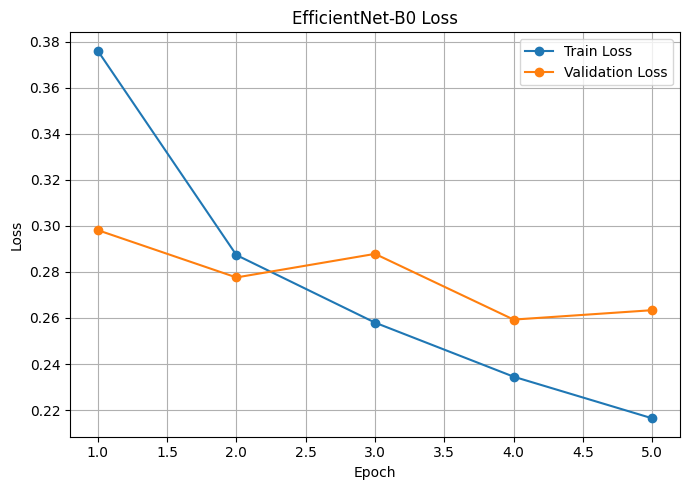

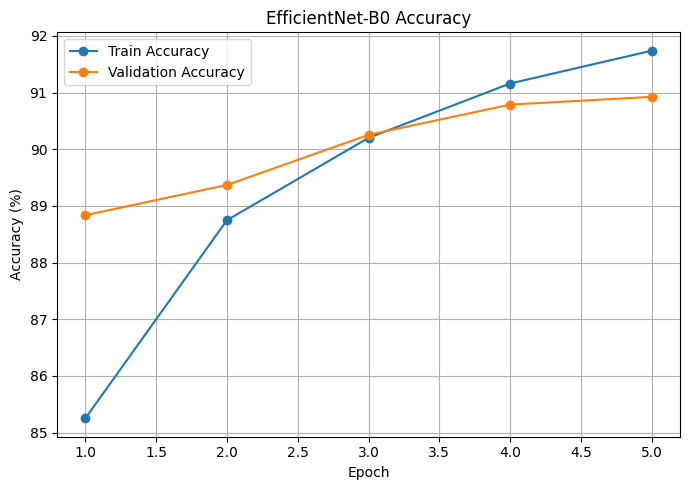

In [15]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EfficientNet-B0 Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "efficientnetb0_loss.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(epochs, [x * 100 for x in history["train_accuracy"]], marker="o", label="Train Accuracy")
plt.plot(epochs, [x * 100 for x in history["val_accuracy"]], marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("EfficientNet-B0 Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "efficientnetb0_accuracy.png", dpi=150)
plt.show()

## 14. Load the best checkpoint

In [16]:
if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(f"Best checkpoint not found: {BEST_MODEL_PATH}")

eval_model = efficientnet_b0(weights=None)
num_features = eval_model.classifier[1].in_features
eval_model.classifier[1] = nn.Linear(num_features, 2)

eval_model.load_state_dict(
    torch.load(BEST_MODEL_PATH, map_location=device)
)
eval_model = eval_model.to(device)
eval_model.eval()

print("Loaded best EfficientNet-B0 checkpoint.")

Loaded best EfficientNet-B0 checkpoint.


## 15. Complete test-set evaluation

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

test_loss, _ = evaluate(eval_model, test_loader, criterion, device)

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)

        outputs = eval_model(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())
        all_probabilities.extend(probabilities[:, 1].cpu().numpy())

if len(all_labels) != len(test_dataset):
    raise RuntimeError(
        f"Only evaluated {len(all_labels)} test images; expected {len(test_dataset)}."
    )

test_accuracy = accuracy_score(all_labels, all_predictions)
test_precision = precision_score(
    all_labels, all_predictions, zero_division=0
)
test_recall = recall_score(
    all_labels, all_predictions, zero_division=0
)
test_f1 = f1_score(
    all_labels, all_predictions, zero_division=0
)
test_roc_auc = roc_auc_score(all_labels, all_probabilities)

print("===================================")
print("EFFICIENTNET-B0 TEST RESULTS")
print("===================================")
print("Test samples evaluated:", len(all_labels))
print(f"Test Loss : {test_loss:.4f}")
print(f"Accuracy  : {test_accuracy * 100:.2f}%")
print(f"Precision : {test_precision * 100:.2f}%  (FAKE = positive class)")
print(f"Recall    : {test_recall * 100:.2f}%")
print(f"F1 Score  : {test_f1 * 100:.2f}%")
print(f"ROC-AUC   : {test_roc_auc:.4f}")

EFFICIENTNET-B0 TEST RESULTS
Test samples evaluated: 6436
Test Loss : 0.2667
Accuracy  : 90.41%
Precision : 91.83%  (FAKE = positive class)
Recall    : 97.17%
F1 Score  : 94.42%
ROC-AUC   : 0.9055


## 16. Confusion matrix and classification report

Confusion Matrix:
[[ 594  465]
 [ 152 5225]]

              precision    recall  f1-score   support

        REAL       0.80      0.56      0.66      1059
        FAKE       0.92      0.97      0.94      5377

    accuracy                           0.90      6436
   macro avg       0.86      0.77      0.80      6436
weighted avg       0.90      0.90      0.90      6436



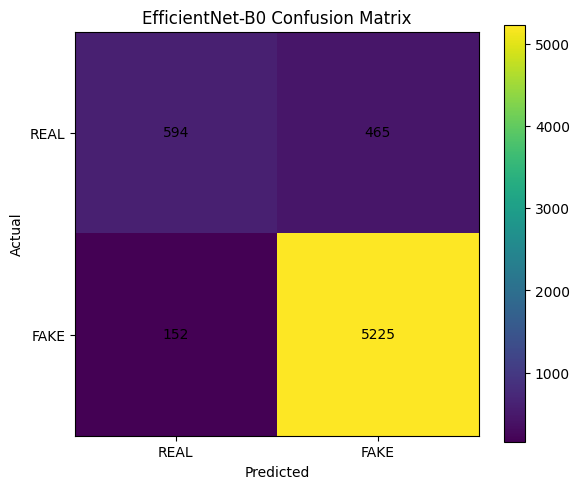

In [18]:
cm = confusion_matrix(all_labels, all_predictions)

print("Confusion Matrix:")
print(cm)
print()

report_dict = classification_report(
    all_labels,
    all_predictions,
    target_names=["REAL", "FAKE"],
    zero_division=0,
    output_dict=True,
)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["REAL", "FAKE"],
        zero_division=0,
    )
)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("EfficientNet-B0 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["REAL", "FAKE"])
plt.yticks([0, 1], ["REAL", "FAKE"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "efficientnetb0_confusion_matrix.png", dpi=150)
plt.show()

## 17. Compare with MobileNetV2 baseline

In [19]:
mobilenet_baseline = {
    "test_accuracy": 0.9024,
    "test_f1_fake": 0.9436,
    "test_roc_auc": 0.9020,
}

print("MODEL COMPARISON")
print("================")
print(f"MobileNetV2   | Accuracy: {mobilenet_baseline['test_accuracy']*100:.2f}% | "
      f"F1(FAKE): {mobilenet_baseline['test_f1_fake']*100:.2f}% | "
      f"ROC-AUC: {mobilenet_baseline['test_roc_auc']:.4f}")

print(f"EfficientNetB0| Accuracy: {test_accuracy*100:.2f}% | "
      f"F1(FAKE): {test_f1*100:.2f}% | "
      f"ROC-AUC: {test_roc_auc:.4f}")

print("\nAccuracy change:",
      f"{(test_accuracy - mobilenet_baseline['test_accuracy'])*100:+.2f} percentage points")
print("ROC-AUC change:",
      f"{test_roc_auc - mobilenet_baseline['test_roc_auc']:+.4f}")

MODEL COMPARISON
MobileNetV2   | Accuracy: 90.24% | F1(FAKE): 94.36% | ROC-AUC: 0.9020
EfficientNetB0| Accuracy: 90.41% | F1(FAKE): 94.42% | ROC-AUC: 0.9055

Accuracy change: +0.17 percentage points
ROC-AUC change: +0.0035


## 18. Save final results

In [20]:
summary = {
    "model": "EfficientNet-B0",
    "dataset_counts": final_counts,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "best_val_accuracy": best_val_accuracy,
    "test_samples_evaluated": len(all_labels),
    "test_accuracy": test_accuracy,
    "test_loss": test_loss,
    "test_precision_fake": test_precision,
    "test_recall_fake": test_recall,
    "test_f1_fake": test_f1,
    "test_roc_auc": test_roc_auc,
    "confusion_matrix": cm.tolist(),
    "classification_report": report_dict,
    "checkpoint_path": str(BEST_MODEL_PATH),
}

summary_path = METRICS_DIR / "efficientnetb0_test_results.json"

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("===================================")
print("FINAL EFFICIENTNET-B0 SUMMARY")
print("===================================")
print(f"Best Val Accuracy : {best_val_accuracy * 100:.2f}%")
print(f"Test Accuracy     : {test_accuracy * 100:.2f}%")
print(f"Test F1 (FAKE)    : {test_f1 * 100:.2f}%")
print(f"Test ROC-AUC      : {test_roc_auc:.4f}")
print("Test samples      :", len(all_labels))
print("Checkpoint exists :", BEST_MODEL_PATH.exists())
print("Checkpoint        :", BEST_MODEL_PATH)
print("Results JSON      :", summary_path)

FINAL EFFICIENTNET-B0 SUMMARY
Best Val Accuracy : 90.93%
Test Accuracy     : 90.41%
Test F1 (FAKE)    : 94.42%
Test ROC-AUC      : 0.9055
Test samples      : 6436
Checkpoint exists : True
Checkpoint        : /content/Deepfake-Detection-KYC/outputs/models/efficientnetb0_baseline_best.pth
Results JSON      : /content/Deepfake-Detection-KYC/outputs/metrics/efficientnetb0_test_results.json


## 19. Download the trained checkpoint
Run this cell **immediately after training/evaluation** so the checkpoint is saved outside the temporary Colab runtime.

In [21]:
from google.colab import files

print("Checkpoint:", BEST_MODEL_PATH)
print("Exists:", BEST_MODEL_PATH.exists())

# Uncomment the next line to download the checkpoint to your computer.
# files.download(str(BEST_MODEL_PATH))

Checkpoint: /content/Deepfake-Detection-KYC/outputs/models/efficientnetb0_baseline_best.pth
Exists: True


## Expected workflow

1. Select **T4 GPU** in Colab.
2. Run cells from top to bottom.
3. Stop if the final dataset sanity check is wrong.
4. Confirm the training output shows the complete training dataset.
5. Let all 5 epochs finish.
6. Record the final test metrics.
7. Run the download cell and uncomment `files.download(...)`.
8. Compare EfficientNet-B0 against the Lab 14 MobileNetV2 baseline.

**MobileNetV2 reference:** 90.24% test accuracy, 0.9020 ROC-AUC.